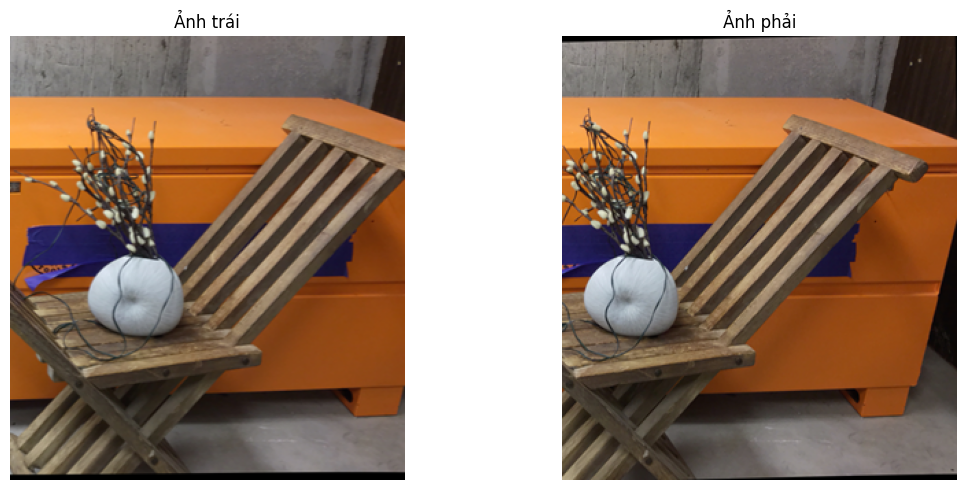

Số keypoints ảnh trái  : 467
Số keypoints ảnh phải  : 370
Số match tốt ban đầu   : 178
Số match stereo hợp lệ : 152

Một số điểm mẫu:
[00] (xL, yL)=(42.5, 167.6), (xR, yR)=(5.7, 167.7), d=36.78 px, Z=0.406 m
[01] (xL, yL)=(45.5, 197.7), (xR, yR)=(6.1, 197.9), d=39.44 px, Z=0.379 m
[02] (xL, yL)=(46.5, 188.6), (xR, yR)=(8.6, 188.6), d=37.90 px, Z=0.394 m
[03] (xL, yL)=(47.8, 227.5), (xR, yR)=(5.3, 227.7), d=42.48 px, Z=0.352 m
[04] (xL, yL)=(50.3, 107.4), (xR, yR)=(8.2, 107.3), d=42.10 px, Z=0.355 m
[05] (xL, yL)=(52.9, 223.8), (xR, yR)=(10.9, 224.0), d=41.98 px, Z=0.356 m
[06] (xL, yL)=(53.0, 105.1), (xR, yR)=(11.0, 105.7), d=41.93 px, Z=0.357 m
[07] (xL, yL)=(54.2, 191.8), (xR, yR)=(14.4, 192.5), d=39.79 px, Z=0.376 m
[08] (xL, yL)=(54.7, 100.8), (xR, yR)=(11.7, 100.9), d=43.00 px, Z=0.348 m
[09] (xL, yL)=(54.7, 100.8), (xR, yR)=(11.7, 100.9), d=43.00 px, Z=0.348 m


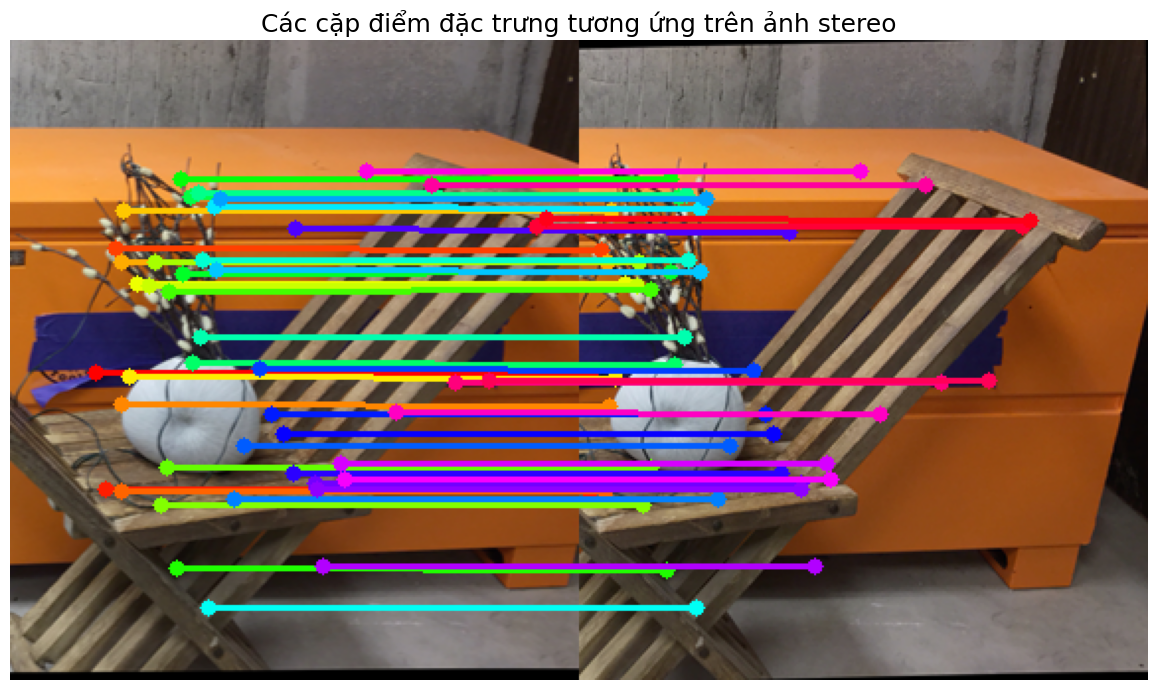

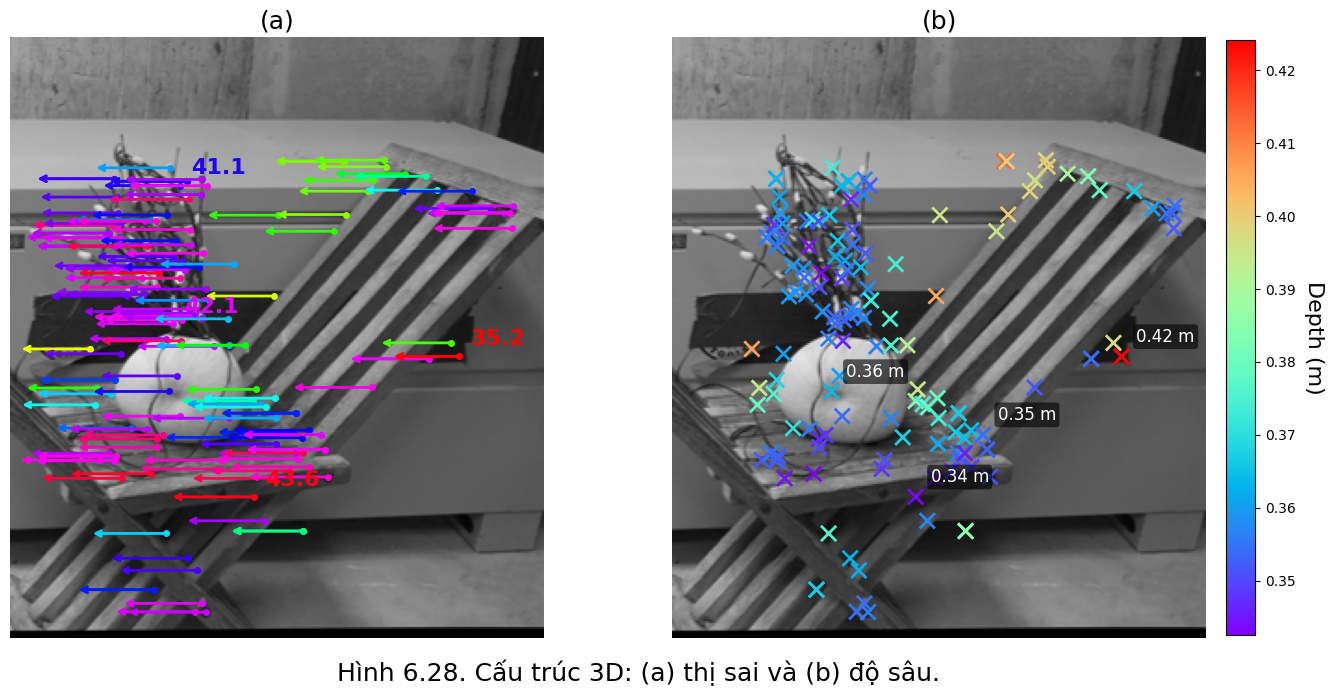


Kiểm tra kết quả:
- Số điểm stereo hợp lệ: 152
- Disparity nhỏ nhất   : 35.25 px
- Disparity lớn nhất   : 43.65 px
- Độ sâu nhỏ nhất      : 0.343 m
- Độ sâu lớn nhất      : 0.424 m
- Code chạy đúng: đã tìm được điểm stereo hợp lệ và ước lượng được độ sâu.


In [1]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: ƯỚC LƯỢNG ĐỘ SÂU TỪ ẢNH STEREO
# Chương/Mục liên quan: Chương 6 - Tái tạo cấu trúc 3D
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa bài toán ước lượng độ sâu từ một cặp ảnh stereo.
# - Giúp người học quan sát mối liên hệ giữa điểm tương ứng, thị sai và độ sâu.
# - Liên hệ phần code với công thức stereo trong giáo trình.

# Sau khi chạy code, người học cần:
# 1. Quan sát được các cặp điểm đặc trưng tương ứng giữa ảnh trái và ảnh phải.
# 2. Hiểu được thị sai d = x_left - x_right.
# 3. Hiểu được độ sâu Z tỉ lệ nghịch với thị sai d.

# Input:
# - Dữ liệu đầu vào: cặp ảnh stereo từ GitHub.
# - Kiểu dữ liệu: ảnh màu, sau đó chuyển sang ảnh xám để phát hiện đặc trưng.

# Output:
# - Ảnh ghép hiển thị các cặp điểm tương ứng.
# - Ảnh minh họa thị sai trên ảnh trái.
# - Ảnh minh họa độ sâu ước lượng tại các điểm đặc trưng.
# - Một số giá trị mẫu của thị sai và độ sâu.

# Lưu ý:
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# Người học không chỉ chạy code để xem kết quả, mà cần hiểu:
# - Code đang minh họa nội dung lý thuyết nào;
# - Các bước xử lý tương ứng với công thức hoặc thuật toán nào;
# - Kết quả đầu ra có hợp lý hay không;
# - Khi thay đổi tham số, kết quả thay đổi như thế nào.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen

# ============================================================
# 2. ĐỊNH NGHĨA CÁC HÀM HỖ TRỢ
# ============================================================

def read_image_from_url(image_url, flags=cv2.IMREAD_COLOR):
    resp = urlopen(image_url)
    img = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    return cv2.imdecode(img, flags)


def make_stereo_canvas(I_left_rgb, I_right_rgb):
    H1, W1 = I_left_rgb.shape[:2]
    H2, W2 = I_right_rgb.shape[:2]
    H = max(H1, H2)

    canvas = np.zeros((H, W1 + W2, 3), dtype=np.uint8)
    canvas[:H1, :W1] = I_left_rgb
    canvas[:H2, W1:W1 + W2] = I_right_rgb

    return canvas


def detect_and_match_keypoints(I_left_gray, I_right_gray, ratio_thresh=0.75):
    sift = cv2.SIFT_create()

    keypoints_left, descriptors_left = sift.detectAndCompute(I_left_gray, None)
    keypoints_right, descriptors_right = sift.detectAndCompute(I_right_gray, None)

    matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
    knn_matches = matcher.knnMatch(descriptors_left, descriptors_right, k=2)

    good_matches = []
    for m, n in knn_matches:
        if m.distance < ratio_thresh * n.distance:
            good_matches.append(m)

    return keypoints_left, keypoints_right, good_matches


def filter_stereo_matches(
    keypoints_left,
    keypoints_right,
    good_matches,
    max_vertical_diff=3.0,
    min_disparity=1.0
):
    stereo_points = []

    for m in good_matches:
        x_left, y_left = keypoints_left[m.queryIdx].pt
        x_right, y_right = keypoints_right[m.trainIdx].pt

        vertical_diff = abs(y_left - y_right)
        disparity = x_left - x_right

        if vertical_diff <= max_vertical_diff and disparity > min_disparity:
            stereo_points.append({
                "x_left": x_left,
                "y_left": y_left,
                "x_right": x_right,
                "y_right": y_right,
                "disparity": disparity
            })

    if len(stereo_points) == 0:
        return stereo_points

    disparities = np.array([p["disparity"] for p in stereo_points], dtype=np.float32)
    d_min = np.percentile(disparities, 5)
    d_max = np.percentile(disparities, 95)

    filtered_points = []
    for p in stereo_points:
        if d_min <= p["disparity"] <= d_max:
            filtered_points.append(p)

    return filtered_points


def estimate_depth_from_disparity(stereo_points, baseline_B=0.065, focal_fx=230.0):
    for p in stereo_points:
        d = p["disparity"]
        p["depth"] = focal_fx * baseline_B / d

    return stereo_points


def draw_matches_on_stereo_canvas(I_left_rgb, I_right_rgb, stereo_points, max_draw=40):
    canvas = make_stereo_canvas(I_left_rgb, I_right_rgb).copy()
    W_left = I_left_rgb.shape[1]

    num_draw = min(max_draw, len(stereo_points))
    if num_draw == 0:
        return canvas

    step_indices = np.linspace(0, len(stereo_points) - 1, num_draw, dtype=int)
    colors = plt.cm.hsv(np.linspace(0, 1, num_draw))[:, :3]
    colors = (255 * colors).astype(np.uint8)

    for i, idx in enumerate(step_indices):
        p = stereo_points[idx]
        color = tuple(int(c) for c in colors[i])

        pt_left = (int(round(p["x_left"])), int(round(p["y_left"])))
        pt_right = (int(round(p["x_right"] + W_left)), int(round(p["y_right"])))

        cv2.circle(canvas, pt_left, 4, color, -1)
        cv2.circle(canvas, pt_right, 4, color, -1)
        cv2.line(canvas, pt_left, pt_right, color, 2)

    return canvas


def choose_label_indices(values, num_labels=4):
    if len(values) == 0:
        return np.array([], dtype=int)

    sort_idx = np.argsort(values)
    picked = np.linspace(0, len(sort_idx) - 1, min(num_labels, len(sort_idx)), dtype=int)
    chosen = sort_idx[picked]

    return np.unique(chosen)


def visualize_disparity_and_depth(I_left_gray, stereo_points, save_path=None):
    if len(stereo_points) == 0:
        raise ValueError("Không có cặp điểm stereo hợp lệ để hiển thị.")

    I_left_vis = cv2.cvtColor(I_left_gray, cv2.COLOR_GRAY2RGB)

    x_left = np.array([p["x_left"] for p in stereo_points], dtype=np.float32)
    y_left = np.array([p["y_left"] for p in stereo_points], dtype=np.float32)
    x_right = np.array([p["x_right"] for p in stereo_points], dtype=np.float32)
    disparities = np.array([p["disparity"] for p in stereo_points], dtype=np.float32)
    depths = np.array([p["depth"] for p in stereo_points], dtype=np.float32)

    disp_min = disparities.min()
    disp_max = disparities.max()
    disp_norm = (disparities - disp_min) / (disp_max - disp_min + 1e-8)
    disp_colors = plt.cm.hsv(disp_norm)

    label_idx_disparity = choose_label_indices(disparities, num_labels=4)
    label_idx_depth = choose_label_indices(depths, num_labels=4)

    fig = plt.figure(figsize=(14, 7))

    ax1 = plt.subplot(1, 2, 1)
    ax1.imshow(I_left_vis, cmap="gray")
    ax1.set_title("(a)", fontsize=18)
    ax1.axis("off")

    for i in range(len(stereo_points)):
        color = disp_colors[i]
        xL = x_left[i]
        yL = y_left[i]
        xR = x_right[i]

        ax1.annotate(
            "",
            xy=(xR, yL),
            xytext=(xL, yL),
            arrowprops=dict(
                arrowstyle="->",
                color=color,
                lw=2,
                shrinkA=0,
                shrinkB=0
            )
        )

        ax1.plot(xL, yL, "o", color=color, markersize=4)

    for idx in label_idx_disparity:
        xL = x_left[idx]
        yL = y_left[idx]
        d = disparities[idx]
        color = disp_colors[idx]

        ax1.text(
            xL + 6,
            yL - 6,
            f"{d:.1f}",
            color=color,
            fontsize=16,
            fontweight="bold"
        )

    ax2 = plt.subplot(1, 2, 2)
    ax2.imshow(I_left_vis, cmap="gray")

    sc = ax2.scatter(
        x_left,
        y_left,
        c=depths,
        cmap="rainbow",
        marker="x",
        s=120,
        linewidths=2
    )

    ax2.set_title("(b)", fontsize=18)
    ax2.axis("off")

    for idx in label_idx_depth:
        x = x_left[idx]
        y = y_left[idx]
        z = depths[idx]

        ax2.text(
            x + 8,
            y - 8,
            f"{z:.2f} m",
            color="white",
            fontsize=12,
            bbox=dict(
                boxstyle="round,pad=0.2",
                fc="black",
                ec="none",
                alpha=0.6
            )
        )

    cbar = plt.colorbar(sc, ax=ax2, fraction=0.046, pad=0.03)
    cbar.set_label("Depth (m)", rotation=270, labelpad=20, fontsize=16)

    fig.text(
        0.5,
        0.02,
        "Hình 6.28. Cấu trúc 3D: (a) thị sai và (b) độ sâu.",
        ha="center",
        fontsize=18
    )

    plt.tight_layout(rect=[0, 0.06, 1, 1])

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

# ============================================================
# 3. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

base_url = "https://github.com/lthavnu/cv-book/raw/main/images/"
left_url = base_url + "chair_left.png"
right_url = base_url + "chair_right.png"

B = 0.065
fx = 230.0
fy = 230.0

I_left_bgr = read_image_from_url(left_url, cv2.IMREAD_COLOR)
I_right_bgr = read_image_from_url(right_url, cv2.IMREAD_COLOR)

if I_left_bgr is None or I_right_bgr is None:
    raise ValueError("Không đọc được ảnh từ URL. Hãy kiểm tra lại đường dẫn.")

I_left_rgb = cv2.cvtColor(I_left_bgr, cv2.COLOR_BGR2RGB)
I_right_rgb = cv2.cvtColor(I_right_bgr, cv2.COLOR_BGR2RGB)

I_left_gray = cv2.cvtColor(I_left_bgr, cv2.COLOR_BGR2GRAY)
I_right_gray = cv2.cvtColor(I_right_bgr, cv2.COLOR_BGR2GRAY)

# ============================================================
# 4. HIỂN THỊ ẢNH ĐẦU VÀO
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(I_left_rgb)
plt.title("Ảnh trái")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(I_right_rgb)
plt.title("Ảnh phải")
plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# 5. XỬ LÝ CHÍNH
# ============================================================

keypoints_left, keypoints_right, good_matches = detect_and_match_keypoints(
    I_left_gray,
    I_right_gray,
    ratio_thresh=0.75
)

print(f"Số keypoints ảnh trái  : {len(keypoints_left)}")
print(f"Số keypoints ảnh phải  : {len(keypoints_right)}")
print(f"Số match tốt ban đầu   : {len(good_matches)}")

stereo_points = filter_stereo_matches(
    keypoints_left,
    keypoints_right,
    good_matches,
    max_vertical_diff=3.0,
    min_disparity=1.0
)

print(f"Số match stereo hợp lệ : {len(stereo_points)}")

stereo_points = estimate_depth_from_disparity(
    stereo_points,
    baseline_B=B,
    focal_fx=fx
)

print("\nMột số điểm mẫu:")

for i, p in enumerate(stereo_points[:10]):
    print(
        f"[{i:02d}] "
        f"(xL, yL)=({p['x_left']:.1f}, {p['y_left']:.1f}), "
        f"(xR, yR)=({p['x_right']:.1f}, {p['y_right']:.1f}), "
        f"d={p['disparity']:.2f} px, "
        f"Z={p['depth']:.3f} m"
    )

# ============================================================
# 6. HIỂN THỊ KẾT QUẢ
# ============================================================

match_canvas = draw_matches_on_stereo_canvas(
    I_left_rgb,
    I_right_rgb,
    stereo_points,
    max_draw=45
)

plt.figure(figsize=(14, 7))
plt.imshow(match_canvas)
plt.axis("off")
plt.title("Các cặp điểm đặc trưng tương ứng trên ảnh stereo", fontsize=18)
plt.tight_layout()
plt.savefig("chair_stereo_matches.png", dpi=200, bbox_inches="tight")
plt.show()

visualize_disparity_and_depth(
    I_left_gray,
    stereo_points,
    save_path="chair_disparity_depth.png"
)

# ============================================================
# 7. KIỂM TRA KẾT QUẢ
# ============================================================

assert I_left_bgr is not None
assert I_right_bgr is not None
assert len(keypoints_left) > 0
assert len(keypoints_right) > 0
assert len(good_matches) > 0
assert len(stereo_points) > 0

disparities = np.array([p["disparity"] for p in stereo_points], dtype=np.float32)
depths = np.array([p["depth"] for p in stereo_points], dtype=np.float32)

assert np.all(disparities > 0)
assert np.all(depths > 0)

print("\nKiểm tra kết quả:")
print(f"- Số điểm stereo hợp lệ: {len(stereo_points)}")
print(f"- Disparity nhỏ nhất   : {disparities.min():.2f} px")
print(f"- Disparity lớn nhất   : {disparities.max():.2f} px")
print(f"- Độ sâu nhỏ nhất      : {depths.min():.3f} m")
print(f"- Độ sâu lớn nhất      : {depths.max():.3f} m")
print("- Code chạy đúng: đã tìm được điểm stereo hợp lệ và ước lượng được độ sâu.")

# ============================================================
# 8. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# 1. Thay đổi ratio_thresh trong hàm detect_and_match_keypoints:
#    - Giá trị nhỏ hơn làm điều kiện matching chặt hơn.
#    - Giá trị lớn hơn giữ lại nhiều match hơn nhưng có thể tăng match sai.

# 2. Thay đổi max_vertical_diff trong hàm filter_stereo_matches:
#    - Ảnh stereo đã rectified thì hai điểm tương ứng gần như nằm cùng hàng.
#    - Giá trị quá lớn có thể giữ lại nhiều match sai.

# 3. Thay đổi baseline_B hoặc focal_fx:
#    - Hai tham số này xuất hiện trực tiếp trong công thức Z = fx * B / d.
#    - Khi B hoặc fx tăng, độ sâu ước lượng cũng tăng nếu disparity giữ nguyên.